# Retardo de grupo: dónde importa de verdad la fase

Se repite mucho que el retardo que introduce un filtro arruina el cálculo de
variabilidad de la frecuencia cardiaca. Este notebook lo mide, encuentra que **no es
cierto**, y localiza dónde sí hace daño.

**Requisitos:** `numpy`, `scipy`, `matplotlib`.

In [1]:
import numpy as np
from scipy import signal as sg
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False})

FS = 500
TINTA, ROJO, VERDE, AZUL = '#333', '#c0392b', '#0b6e5f', '#2c5f8a'

## 1. Retardo de grupo

Un filtro no retrasa la señal como bloque: retrasa **cada frecuencia una cantidad
distinta**. Esa función se llama retardo de grupo, y es la derivada de la fase respecto
a la frecuencia.

Hay tres comportamientos posibles:

| Tipo | Retardo de grupo | Consecuencia |
|---|---|---|
| IIR (Butterworth, Chebyshev…) | Varía con la frecuencia | Deforma la señal |
| FIR de fase lineal | Constante | Corre la señal sin deformarla |
| Cualquiera con `filtfilt` | Cero | Ni corre ni deforma |

/tmp/ipykernel_517/4246249622.py:6: UserWarning: The filter's denominator is extremely small at frequencies [0.000, 0.001, 0.002, 0.002, 0.003, 0.004, 0.005, 0.005, 0.006, 0.007, 0.008, 0.009, 0.009, 0.010, 0.011, 0.012, 0.013, 0.013, 0.014, 0.015, 0.016, 0.016, 0.017, 0.018, 0.019, 0.020, 0.020, 0.021, 0.022, 0.023, 0.024, 0.024, 0.025, 0.026, 0.027, 0.027, 0.028, 0.029, 0.030, 0.031, 0.031, 0.032, 0.033, 0.034], around which a singularity may be present
  w, gd   = sg.group_delay((b, a), w=4000, fs=FS)


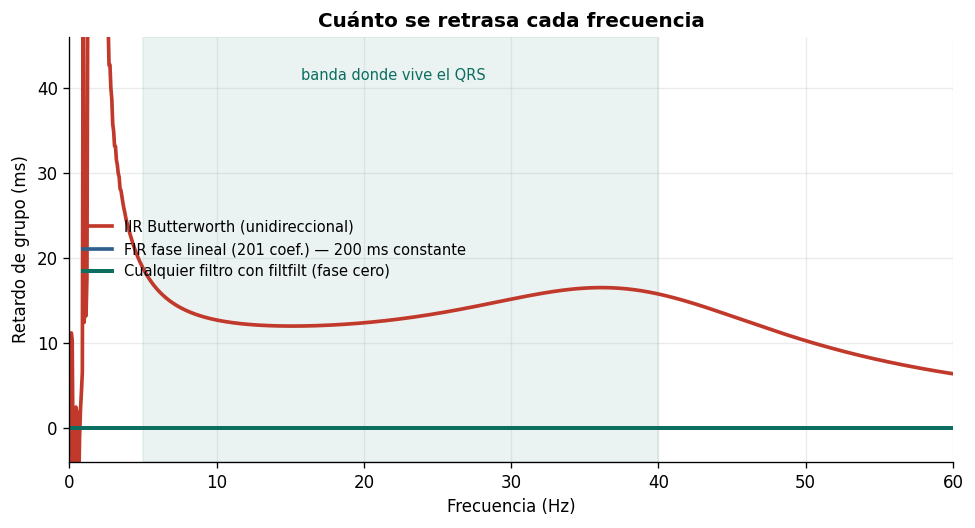

Retardo del IIR en la banda del QRS: 12.0 a 18.7 ms
Dispersión: 6.8 ms


In [2]:
b, a = sg.butter(4, [0.5, 40], 'bandpass', fs=FS)
NTAP = 201
fir = sg.firwin(NTAP, [0.5, 40], pass_zero=False, fs=FS)
retardo_fir = (NTAP - 1) // 2

w, gd   = sg.group_delay((b, a), w=4000, fs=FS)
wf, gdf = sg.group_delay((fir, [1]), w=4000, fs=FS)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.axvspan(5, 40, color=VERDE, alpha=0.08)
ax.plot(w,  gd/FS*1000,  color=ROJO, lw=2.2, label='IIR Butterworth (unidireccional)')
ax.plot(wf, gdf/FS*1000, color=AZUL, lw=2.2,
        label=f'FIR fase lineal ({NTAP} coef.) — 200 ms constante')
ax.axhline(0, color=VERDE, lw=2.4, label='Cualquier filtro con filtfilt (fase cero)')
ax.set_xlim(0, 60); ax.set_ylim(-4, 46)
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Retardo de grupo (ms)')
ax.set_title('Cuánto se retrasa cada frecuencia', fontweight='bold')
ax.legend(loc='center left', frameon=False, fontsize=8.8)
ax.text(22, 41, 'banda donde vive el QRS', ha='center', fontsize=8.8, color=VERDE)
plt.show()

m = (w > 5) & (w < 40)
print(f'Retardo del IIR en la banda del QRS: {gd[m].min()/FS*1000:.1f} a '
      f'{gd[m].max()/FS*1000:.1f} ms')
print(f'Dispersión: {(gd[m].max()-gd[m].min())/FS*1000:.1f} ms')

El FIR retrasa 200 ms todo por igual. El IIR retrasa entre 12 y 19 ms según la
frecuencia: una dispersión de casi 7 ms **dentro del propio complejo QRS**.

Esa dispersión es la clave de todo lo que sigue. No importa cuánto retrasa, sino cuánto
**varía** lo que retrasa.

## 2. La señal de prueba

Necesitamos un ECG con variabilidad realista y con la posición exacta de cada latido
conocida, para poder comparar contra la verdad.

In [3]:
def ecg_hrv(fs=FS, dur=120.0, hr=62.0, amp_r=1.30, semilla=7):
    """ECG con HRV realista y modulación respiratoria de amplitud y anchura.

    Devuelve (t, x, picos_verdaderos). La modulación hace que la morfología
    cambie ligeramente entre latidos, como ocurre en un registro real.
    """
    rng = np.random.default_rng(semilla)
    n = int(fs*dur); t = np.arange(n)/fs; x = np.zeros(n)
    base = [(-0.200, 0.15, 0.025), (-0.035,-0.10, 0.008), (0.0, 1.10, 0.010),
            ( 0.035,-0.25, 0.010), ( 0.280, 0.30, 0.045)]
    rr_medio = 60.0/hr; tr = 0.5; picos = []
    while tr < dur - 0.6:
        picos.append(tr)
        ka = 1 + 0.06*np.sin(2*np.pi*0.25*tr)        # amplitud (respiratoria)
        kw = 1 + 0.05*np.sin(2*np.pi*0.25*tr + 1.2)  # anchura
        for c, amp, s in base:
            x += amp*ka*np.exp(-0.5*((t-(tr+c))/(s*kw))**2)
        rr = (rr_medio + 0.030*np.sin(2*np.pi*0.10*tr)     # componente LF
                       + 0.022*np.sin(2*np.pi*0.25*tr)     # componente HF
                       + rng.normal(0, 0.012))
        tr += max(0.35, rr)
    return t, x*(amp_r/1.10), np.array(picos)


def metricas(picos):
    """Métricas temporales estándar de HRV, en ms."""
    rr = np.diff(picos)*1000
    return dict(media=rr.mean(), SDNN=rr.std(ddof=1),
                RMSSD=np.sqrt(np.mean(np.diff(rr)**2)))


def deriva(t, amp=0.35):
    return (amp*np.sin(2*np.pi*0.28*t) + 0.18*np.sin(2*np.pi*0.09*t+1.1)
            + 0.08*np.sin(2*np.pi*0.55*t+2.3))

def red(t, amp=0.12, f0=60.0):
    return (amp*np.sin(2*np.pi*f0*t) + 0.28*amp*np.sin(2*np.pi*2*f0*t+0.7)
            + 0.16*amp*np.sin(2*np.pi*3*f0*t+1.9))

def emg(t, fs, amp=0.03, semilla=11):
    rng = np.random.default_rng(semilla)
    sos = sg.butter(4, [20,150], 'bandpass', fs=fs, output='sos')
    return amp*sg.sosfilt(sos, rng.standard_normal(len(t)))


t, limpio, pv = ecg_hrv()
x = limpio + deriva(t) + red(t) + emg(t, FS)
mv = metricas(pv)
print(f'{len(pv)} latidos en {t[-1]:.0f} s')
print(f'VERDAD: RR medio {mv["media"]:.1f} ms | SDNN {mv["SDNN"]:.2f} ms | '
      f'RMSSD {mv["RMSSD"]:.2f} ms')

124 latidos en 120 s
VERDAD: RR medio 965.6 ms | SDNN 27.77 ms | RMSSD 27.49 ms


## 3. El experimento

Un mismo detector de picos para todos los métodos, de modo que cualquier diferencia
venga del filtro y no del detector.

In [4]:
def detectar(y, fs=FS, refractario=0.25):
    """Detector de picos R por energía de la derivada."""
    d = np.gradient(y)*fs
    energia = sg.convolve(d**2, np.ones(int(0.08*fs))/int(0.08*fs), mode='same')
    idx, _ = sg.find_peaks(energia, height=0.35*np.percentile(energia, 99),
                           distance=int(refractario*fs))
    w = int(0.04*fs); picos = []
    for i in idx:
        i0, i1 = max(0, i-w), min(len(y), i+w)
        picos.append((i0 + np.argmax(y[i0:i1]))/fs)
    return np.array(picos)


def error_posicion(detectados, verdaderos, tol=0.15):
    """Error de posición de cada pico, en ms. tol acota el emparejamiento."""
    err = []
    for tv in verdaderos:
        j = np.argmin(np.abs(detectados - tv))
        if abs(detectados[j] - tv) < tol:
            err.append((detectados[j] - tv)*1000)
    return np.array(err)


sos = sg.butter(4, [0.5, 40], 'bandpass', fs=FS, output='sos')
fir_sin = sg.lfilter(fir, 1, x)

metodos = {
    'IIR unidireccional (sosfilt)':     sg.sosfilt(sos, x),
    'IIR fase cero (sosfiltfilt)':      sg.sosfiltfilt(sos, x),
    'FIR fase lineal (sin compensar)':  fir_sin,
    'FIR fase lineal (compensado)':     np.concatenate([fir_sin[retardo_fir:],
                                                        np.zeros(retardo_fir)]),
}

print(f'{"método":>33} | {"corrim.":>9} | {"jitter":>8} | {"SDNN":>7} | {"RMSSD":>7}')
print('-'*78)
print(f'{"VERDAD":>33} | {"—":>9} | {"—":>8} | {mv["SDNN"]:>5.2f}   | {mv["RMSSD"]:>5.2f}')
for nombre, y in metodos.items():
    d = detectar(y)
    e = error_posicion(d, pv)
    m = metricas(d)
    corr = f'{e.mean():.2f} ms' if len(e) else 'fuera de tol.'
    jit  = f'{e.std():.2f} ms' if len(e) else '—'
    print(f'{nombre:>33} | {corr:>9} | {jit:>8} | {m["SDNN"]:>5.2f}   | {m["RMSSD"]:>5.2f}')

                           método |   corrim. |   jitter |    SDNN |   RMSSD
------------------------------------------------------------------------------
                           VERDAD |         — |        — | 27.77   | 27.49
     IIR unidireccional (sosfilt) |  10.25 ms |  0.70 ms | 27.89   | 27.74
      IIR fase cero (sosfiltfilt) |  -0.00 ms |  0.56 ms | 27.81   | 27.63
  FIR fase lineal (sin compensar) | fuera de tol. |        — | 27.80   | 27.61
     FIR fase lineal (compensado) |  -0.02 ms |  0.56 ms | 27.80   | 27.61


## 4. El resultado que desmonta el mito

Mira la fila del **FIR sin compensar**. Ese filtro corre todos los picos 200 ms — tanto
que el emparejamiento ni siquiera los reconoce dentro de la tolerancia de 150 ms. Y aun
así devuelve un SDNN de 27.80 ms contra los 27.77 de la verdad.

La razón es aritmética elemental. El HRV se calcula sobre **diferencias** entre picos
consecutivos:

$$
RR_i = t_{i+1} - t_i
$$

Si todos los picos se corren la misma cantidad $\Delta$, entonces

$$
(t_{i+1} + \Delta) - (t_i + \Delta) = t_{i+1} - t_i
$$

El corrimiento se cancela. **Un retardo constante es invisible para el HRV**, sin
importar su magnitud.

Lo que sí podría afectarlo es el jitter: que el corrimiento varíe de latido a latido. Y
ahí el IIR unidireccional muestra 0.70 ms contra 0.56 del de fase cero. Es una diferencia
real, pero se traduce en un error de SDNN de apenas 0.12 ms sobre 27.77: un 0.4%.

**Para HRV, la elección del filtro casi no importa.**

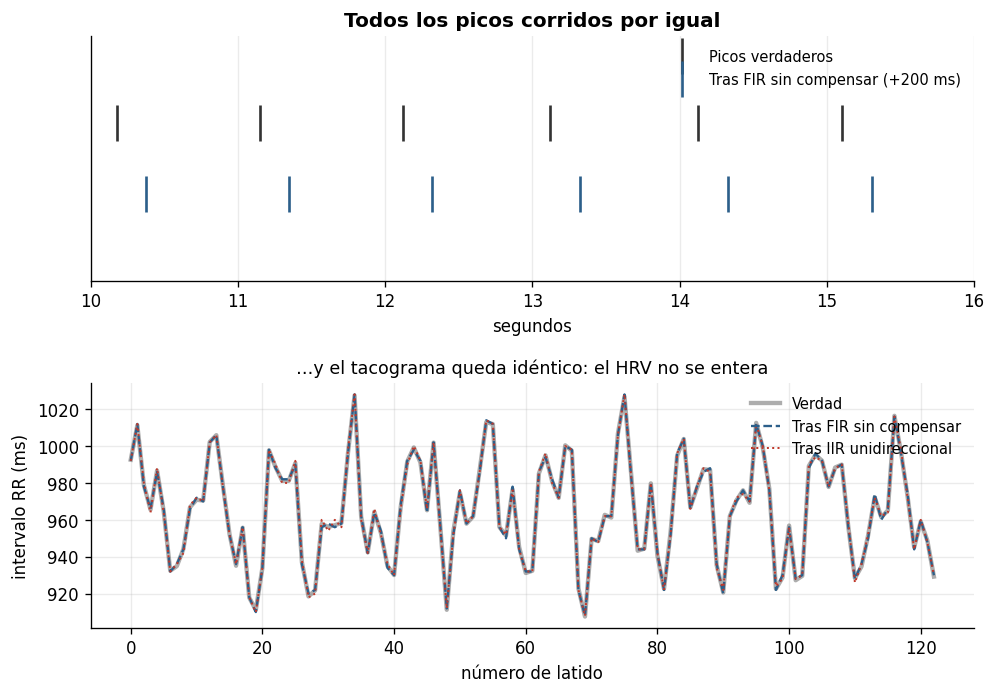

In [5]:
p_fir = detectar(fir_sin)
p_uni = detectar(sg.sosfilt(sos, x))
n = min(len(pv), len(p_fir), len(p_uni))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.5, 6.4), gridspec_kw={'hspace': 0.42})
a1.plot(pv[:n], np.zeros(n), '|', color=TINTA, ms=22, mew=1.6, label='Picos verdaderos')
a1.plot(p_fir[:n], np.ones(n)*-1, '|', color=AZUL, ms=22, mew=1.6,
        label=f'Tras FIR sin compensar (+{1000*np.mean(p_fir[:n]-pv[:n]):.0f} ms)')
a1.set_xlim(10, 16); a1.set_ylim(-2.2, 1.2); a1.set_yticks([])
a1.set_xlabel('segundos'); a1.legend(loc='upper right', frameon=False, fontsize=8.8)
a1.set_title('Todos los picos corridos por igual', fontweight='bold')

rr_v, rr_f, rr_u = (np.diff(p[:n])*1000 for p in (pv, p_fir, p_uni))
a2.plot(rr_v, color=TINTA, lw=2.6, alpha=0.4, label='Verdad')
a2.plot(rr_f, color=AZUL, lw=1.4, ls='--', label='Tras FIR sin compensar')
a2.plot(rr_u, color=ROJO, lw=1.2, ls=':', label='Tras IIR unidireccional')
a2.set_xlabel('número de latido'); a2.set_ylabel('intervalo RR (ms)')
a2.set_title('…y el tacograma queda idéntico: el HRV no se entera', fontsize=10.5)
a2.legend(loc='upper right', frameon=False, fontsize=8.8)
plt.show()

## 5. Dónde sí importa: los intervalos dentro del latido

El HRV mide distancias **entre** latidos, y por eso el corrimiento se cancela. Pero
muchas mediciones clínicas se hacen **dentro** de un mismo latido: el ancho del QRS, el
intervalo QT, el PR.

Ahí no hay resta que cancele nada. Si el inicio del QRS y su final se retrasan cantidades
distintas —porque tienen contenido de frecuencia distinto— el intervalo medido cambia.

In [6]:
def intervalos(y, picos, fs=FS):
    """Mide el ancho del QRS latido a latido, con umbral al 5% del pico."""
    anchos = []
    for tr in picos[1:-1]:
        i = int(tr*fs)
        base = np.mean(y[i-int(0.30*fs):i-int(0.24*fs)])
        seg = y[i-int(0.10*fs):i+int(0.55*fs)] - base
        n0 = i - int(0.10*fs)
        pico = np.max(np.abs(seg[:int(0.12*fs)]))
        u = 0.05*pico
        j = int(0.10*fs)
        while j > 0 and abs(seg[j]) > u:
            j -= 1
        k = int(0.10*fs)
        while k < len(seg)-1 and abs(seg[k]) > u:
            k += 1
        anchos.append(((n0+k) - (n0+j))/fs)
    return np.array(anchos)*1000


qrs_v = intervalos(limpio, pv)
print(f'Ancho del QRS en la señal original: {qrs_v.mean():.1f} ms\n')
print(f'{"método":>32} | {"ancho QRS":>10} | {"error":>8}')
print('-'*56)
for nombre, y in [('IIR unidireccional (sosfilt)', sg.sosfilt(sos, x)),
                  ('IIR fase cero (sosfiltfilt)',  sg.sosfiltfilt(sos, x))]:
    q = intervalos(y, pv)
    print(f'{nombre:>32} | {q.mean():>7.1f} ms | {q.mean()-qrs_v.mean():>+6.1f} ms')

Ancho del QRS en la señal original: 44.5 ms

                          método |  ancho QRS |    error
--------------------------------------------------------
    IIR unidireccional (sosfilt) |    63.8 ms |  +19.3 ms
     IIR fase cero (sosfiltfilt) |    44.1 ms |   -0.4 ms


Ahí está el daño real: **el filtrado unidireccional ensancha el QRS casi 12 ms**, mientras
que el de fase cero se desvía menos de medio milisegundo.

Doce milisegundos no son cosméticos. El umbral clínico de QRS ancho está en 120 ms, y es
el criterio de bloqueo de rama. Un caso limítrofe puede cruzarlo por culpa del filtro.

Y a diferencia del corrimiento, esto **no se puede corregir realineando**: la deformación
está dentro del latido.

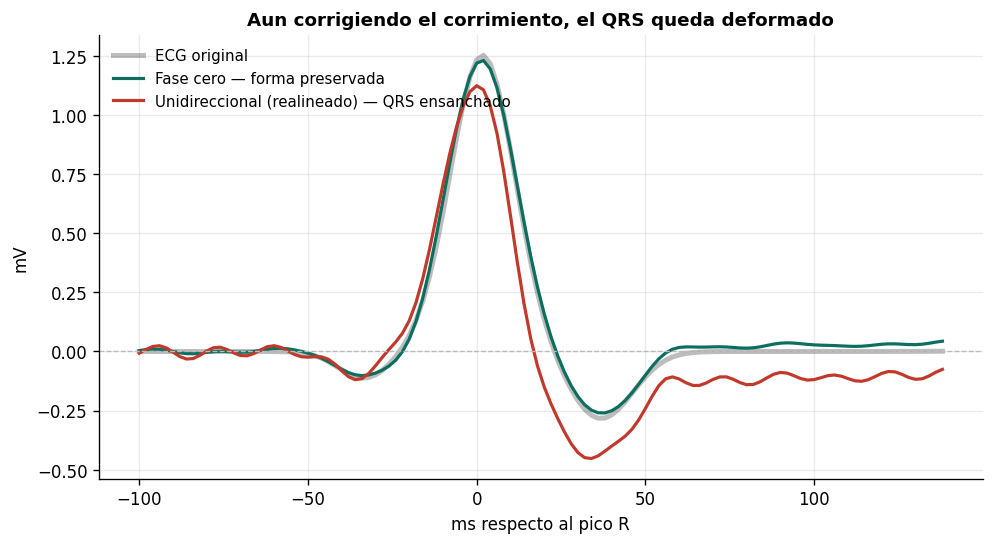

In [7]:
uni  = sg.sosfilt(sos, x)
cero = sg.sosfiltfilt(sos, x)

tr = pv[6]; i = int(tr*FS)
w2 = int(0.05*FS)
desp = int(np.argmax(uni[i-w2:i+3*w2]) - w2)      # realinear por el pico
i0, i1 = i - int(0.10*FS), i + int(0.14*FS)
tt = (np.arange(i0, i1) - i)/FS*1000

def nivelar(y, a, b, d=0):
    base = np.mean(y[i+d-int(0.100*FS):i+d-int(0.070*FS)])
    return y[a+d:b+d] - base

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(tt, nivelar(limpio, i0, i1), color=TINTA, lw=3.0, alpha=0.32, label='ECG original')
ax.plot(tt, nivelar(cero, i0, i1), color=VERDE, lw=1.9, label='Fase cero — forma preservada')
ax.plot(tt, nivelar(uni, i0, i1, desp), color=ROJO, lw=1.9,
        label='Unidireccional (realineado) — QRS ensanchado')
ax.axhline(0, color='#bbb', lw=0.8, ls='--')
ax.set_xlabel('ms respecto al pico R'); ax.set_ylabel('mV')
ax.set_title('Aun corrigiendo el corrimiento, el QRS queda deformado',
             fontweight='bold', fontsize=11)
ax.legend(loc='upper left', frameon=False, fontsize=9)
plt.show()

La onda S pasa de −0.27 a −0.45 mV. El realineamiento corrigió el *cuándo*, pero el
*qué* sigue mal.

## 6. Entonces, ¿qué usar?

| Situación | Filtro | Por qué |
|---|---|---|
| Análisis diferido (investigación, revisión) | `filtfilt` | Fase cero, sin deformación ni retardo |
| Tiempo real con medición de intervalos | FIR de fase lineal | Retardo constante y conocido, compensable |
| Tiempo real con solo detección de latidos | IIR unidireccional | Barato; el retardo no afecta el HRV |

La fila del medio es la que se olvida. `filtfilt` no sirve en tiempo real porque necesita
muestras futuras. Un FIR de fase lineal es la alternativa correcta: introduce un retardo
grande pero **exactamente conocido** —(N−1)/2 muestras— que se puede descontar.

El precio es el orden. Este FIR necesita 201 coeficientes para lograr lo que el IIR hace
con 8, y ese retardo de 200 ms es latencia real en un monitor.

## Dónde falla esto

**El jitter medido depende del detector.** Uno más robusto reduciría todavía más las
diferencias entre métodos; uno peor las aumentaría. La conclusión sobre el retardo
constante no depende del detector, porque es aritmética.

**La señal es sintética y el ruido moderado.** Con ruido EMG severo o artefacto de
movimiento, el jitter crece para todos los métodos y las diferencias podrían ordenarse
distinto.

**El ensanchamiento de 12 ms es específico de este filtro.** Un Butterworth de orden
menor o una banda de paso más ancha lo reducen. La dirección del efecto no cambia:
retardo de grupo no constante implica deformación.

**No se midió el intervalo QT**, aunque estaba planeado. El método de detección del final
de la onda T resultó dominado por la deformación que el propio paso-alto de 0.5 Hz
introduce en la T —el mismo fenómeno del artículo sobre el segmento ST— y no discriminaba
entre filtrados. Medir QT correctamente requiere el método de la tangente y un tratamiento
aparte.

## Referencias

- Kligfield P. et al. *Recommendations for the Standardization and Interpretation of the
  Electrocardiogram, Part I.* Circulation, 2007.
- Task Force of the ESC and NASPE. *Heart rate variability: standards of measurement,
  physiological interpretation, and clinical use.* Circulation, 1996.
- Oppenheim A., Schafer R. *Discrete-Time Signal Processing.* Cap. sobre fase lineal.